In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('online_retail_combined.csv')
print("Shape:", df.shape)
print(df.head())

#What happens in this code?

# # 1. Imported essential libraries for data manipulation, visualization, clustering, dimensionality reduction and anomaly detection.
# 2. Suppressed warning messages for cleaner notebook output.
# 3. Loaded the Online Retail dataset using Pandas.
# 4. Displayed the shape of the dataset to know the number of rows and columns.
# 5. Displayed the first 5 rows using head() to understand the structure of the dataset.

Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [13]:
# Remove missing customer IDs
df = df.dropna(subset=['Customer ID'])

# Remove returns (negative quantity)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Fix data types
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Add total amount
df['TotalAmount'] = df['Quantity'] * df['Price']

print("Clean shape:", df.shape)
print("Unique customers:", df['Customer ID'].nunique())

# What happens in this code?

# 1. Removed rows with missing Customer IDs because customer segmentation requires customer information.
# 2. Removed return transactions by keeping only positive Quantity values.
# 3. Removed rows with zero or negative prices.
# 4. Converted Customer ID from float to integer.
# 5. Converted InvoiceDate from string to datetime format for date calculations.
# 6. Created a new feature TotalAmount by multiplying Quantity and Price.
# 7. Printed the cleaned dataset shape and the number of unique customers.

# Result:
# The dataset is cleaned and ready for RFM feature engineering and customer segmentation.

Clean shape: (805549, 9)
Unique customers: 5878


In [14]:
# Reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),#Number of days since the customers last purchase.
    Frequency = ('Invoice',      'nunique'),# frequency of the client purschas 
    Monetary  = ('TotalAmount',  'sum')#how much they spent 
).reset_index()

print("RFM shape:", rfm.shape)
print(rfm.head())
print(rfm.describe())

# What happens in this code?

# 1. Created a reference date by taking the maximum InvoiceDate and adding one day.
# 2. Grouped transactions by Customer ID.
# 3. Calculated Recency as the number of days since the customer's last purchase.
# 4. Calculated Frequency as the number of unique invoices per customer.
# 5. Calculated Monetary as the total amount spent by each customer.
# 6. Reset the index to convert Customer ID back to a normal column.
# 7. Displayed the shape, first few rows, and descriptive statistics of the RFM table.

# Result:
# Created an RFM table where each row represents a customer with Recency, Frequency, and Monetary values, which will be used for customer segmentation using K-Means clustering.

RFM shape: (5878, 4)
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


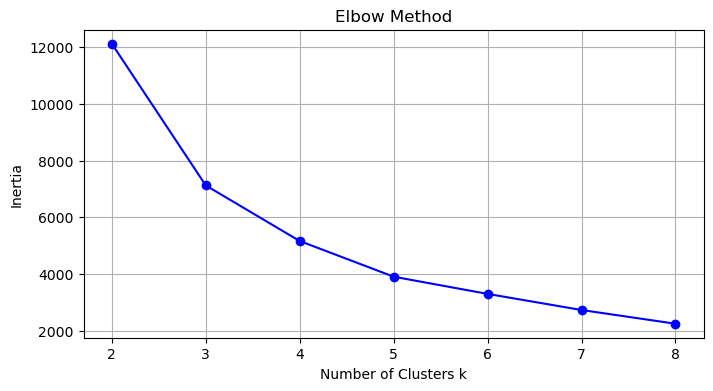

In [15]:
# Scale features
features = ['Recency', 'Frequency', 'Monetary']
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])

# Elbow method
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)#Total squared distance between data points and their cluster centers.

plt.figure(figsize=(8,4))
plt.plot(range(2,9), inertias, 'bo-')
plt.xlabel('Number of Clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# What happens in this code?

# 1. Selected Recency, Frequency, and Monetary as features for clustering.
# 2. Standardized the features using StandardScaler so that all features have mean 0 and standard deviation 1.
# 3. Initialized an empty list to store inertia values.
# 4. Trained K-Means for different numbers of clusters (k=2 to k=8).
# 5. Calculated inertia for each k value and stored it.
# 6. Plotted the Elbow Curve using inertia values.
# 7. Used the elbow point in the graph to determine the optimal number of customer clusters.

# Result:
# The Elbow Method helps identify the best number of clusters for customer segmentation before training the final K-Means model.

In [16]:
# Apply with k=4
kmeans       = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(rfm['Cluster'].value_counts())

# What happens in this code?

# 1. Created a K-Means model with 4 clusters using the optimal K obtained from the Elbow Method.
# 2. Used fit_predict() to train the model and assign cluster labels to each customer.
# 3. Added the predicted cluster labels as a new column called 'Cluster' in the RFM table.
# 4. Counted the number of customers in each cluster using value_counts().

# Result:
# Each customer is assigned to one of four clusters based on their Recency, Frequency, and Monetary values. The dataset is now segmented and ready for cluster analysis and interpretation.

Cluster distribution:
Cluster
1    3841
0    1998
2      35
3       4
Name: count, dtype: int64


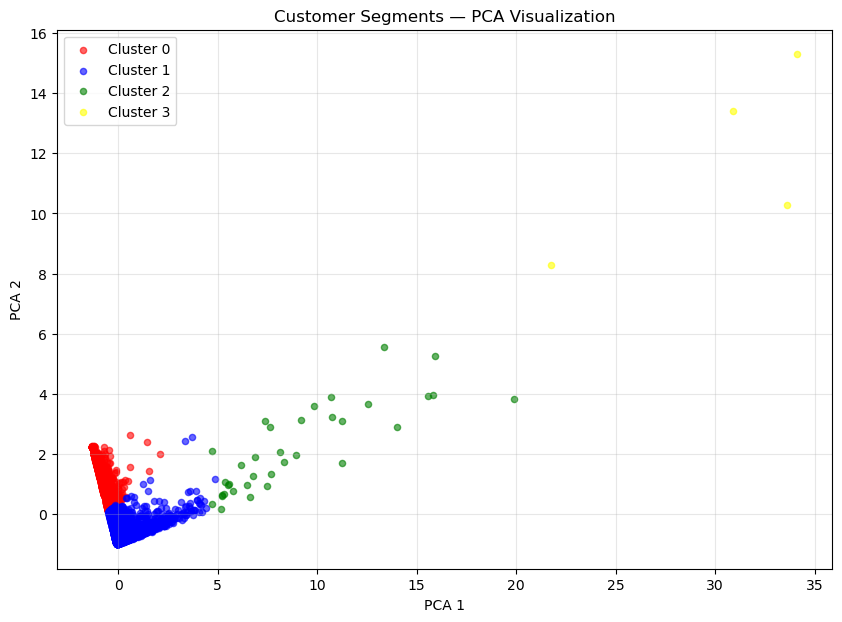

In [19]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

rfm['PCA1'] = X_pca[:, 0]
rfm['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'yellow']

for cluster in range(4):
    mask = rfm['Cluster'] == cluster
    plt.scatter(
        rfm.loc[mask, 'PCA1'],
        rfm.loc[mask, 'PCA2'],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        alpha=0.6, s=20
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segments — PCA Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# What happens in this code?

# 1. Created a PCA model with 2 principal components.
# 2. Reduced the scaled RFM features from 3 dimensions (Recency, Frequency, Monetary) to 2 dimensions (PCA1, PCA2).
# 3. Added PCA1 and PCA2 columns to the RFM dataframe.
# 4. Created a scatter plot for each cluster using PCA1 and PCA2.
# 5. Assigned different colors to each cluster for better visualization.
# 6. Displayed the final graph showing customer segments.

# Result:
# PCA transforms the 3-dimensional RFM data into 2 dimensions so that customer clusters created by K-Means can be visualized on a 2D graph.

Anomalies found: 294
Normal customers: 5584


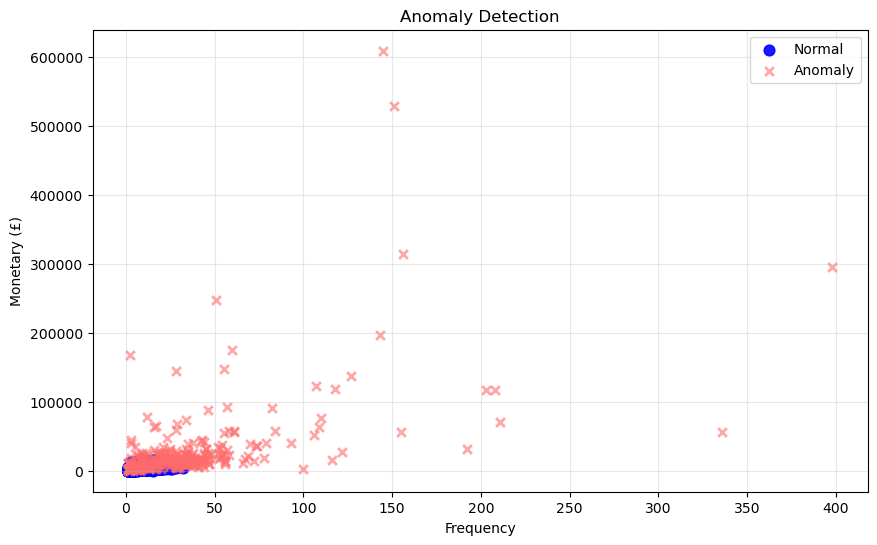

In [25]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)
rfm['Is_Anomaly'] = iso.fit_predict(X_scaled) == -1

print(f"Anomalies found: {rfm['Is_Anomaly'].sum()}")
print(f"Normal customers: {(~rfm['Is_Anomaly']).sum()}")

# Plot
plt.figure(figsize=(10,6))
normal  = rfm[~rfm['Is_Anomaly']]
anomaly = rfm[rfm['Is_Anomaly']]

plt.scatter(normal['Frequency'], normal['Monetary'],
            c='blue', alpha=0.9, s=60, label='Normal')
plt.scatter(anomaly['Frequency'], anomaly['Monetary'],
            c='#FF6B6B', alpha=0.6, s=40,
            marker='x', linewidths=2, label='Anomaly')
plt.xlabel('Frequency')
plt.ylabel('Monetary (£)')
plt.title('Anomaly Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# What happens in this code?

# 1. Created an Isolation Forest model for anomaly detection.
# 2. Set contamination=0.05, assuming approximately 5% of customers are anomalies.
# 3. Trained the model using scaled RFM features.
# 4. Predicted anomalies and stored the results in a new column called Is_Anomaly.
# 5. Counted the number of anomalous and normal customers.
# 6. Created a scatter plot using Frequency and Monetary.
# 7. Displayed normal customers as turquoise circles and anomalies as red X markers.

# Result:
# Isolation Forest identifies customers whose purchasing behavior is significantly different from the majority, helping detect outliers and unusual customer segments.

In [31]:
# Cluster summary
summary = rfm.groupby('Cluster').agg(
    Count     = ('Customer ID', 'count'),
    Recency   = ('Recency',     'mean'),
    Frequency = ('Frequency',   'mean'),
    Monetary  = ('Monetary',    'mean')
).round(2)

cluster_names = {
    0: "Lost Customers ",
    1: "Regular Customers ",
    2: "VIP Customers ",
    3: "Whale Customers "
}

# ==============================
# CUSTOMER SEGMENTATION DASHBOARD
# ==============================

print("="*50)
print("      CUSTOMER SEGMENTATION DASHBOARD")
print("="*50)

# Total customers
print(f" Total Customers : {rfm.shape[0]}")

# Total Revenue
print(f"Total Revenue   : £{rfm['Monetary'].sum():,.0f}")

# Number of anomalies
print(f"Anomalies Found : {rfm['Is_Anomaly'].sum()}")

print("="*50)

# Cluster summary
for cluster in summary.index:

    print(f"\n🔹 {cluster_names[cluster]}")

    print(f"Customers : {summary.loc[cluster,'Count']:.0f}")

    print(f"Recency   : {summary.loc[cluster,'Recency']:.1f} days")

    print(f"Frequency : {summary.loc[cluster,'Frequency']:.1f} orders")

    print(f"Monetary  : £{summary.loc[cluster,'Monetary']:,.0f}")

print("="*50)

# Save results
rfm.to_csv('rfm_final.csv', index=False)
print("\nSaved to rfm_final.csv!")

      CUSTOMER SEGMENTATION DASHBOARD
 Total Customers : 5878
Total Revenue   : £17,743,429
Anomalies Found : 294

🔹 Lost Customers 
Customers : 1998
Recency   : 463.0 days
Frequency : 2.2 orders
Monetary  : £765

🔹 Regular Customers 
Customers : 3841
Recency   : 67.0 days
Frequency : 7.3 orders
Monetary  : £3,009

🔹 VIP Customers 
Customers : 35
Recency   : 25.9 days
Frequency : 103.7 orders
Monetary  : £83,086

🔹 Whale Customers 
Customers : 4
Recency   : 3.5 days
Frequency : 212.5 orders
Monetary  : £436,836

Saved to rfm_final.csv!


In [32]:
plt.savefig("pca_visualization.png", bbox_inches='tight')

plt.savefig("anomaly_detection.png", bbox_inches='tight') 

<Figure size 640x480 with 0 Axes>